<a href="https://colab.research.google.com/github/jMino345/Handwritten-Digit-Classification-Python/blob/main/Handwritten_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


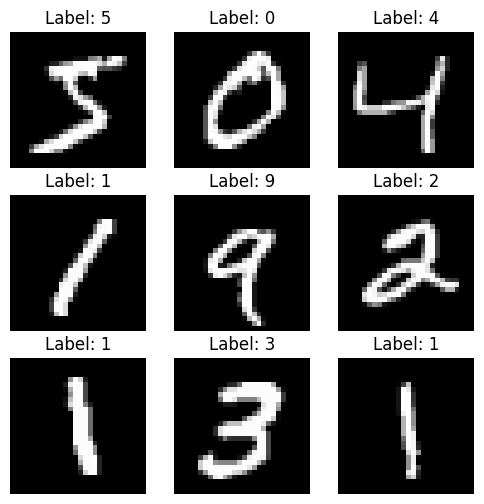

In [3]:
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label: " + str(y_train[i]))
    plt.axis('off')

plt.show()


In [4]:
# Normalize (scaling)
x_train = x_train / 255.0
x_test = x_test / 255.0


In [5]:
model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),   # convert image to 1D
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')  # 10 digits (0–9)
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [7]:
history = model.fit(
    x_train, y_train,
    epochs=3,
    validation_data=(x_test, y_test)
)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9264 - loss: 0.2575 - val_accuracy: 0.9581 - val_loss: 0.1353
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9668 - loss: 0.1130 - val_accuracy: 0.9688 - val_loss: 0.0976
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9766 - loss: 0.0783 - val_accuracy: 0.9765 - val_loss: 0.0769


In [9]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9765 - loss: 0.0769
Test Accuracy: 0.9764999747276306


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


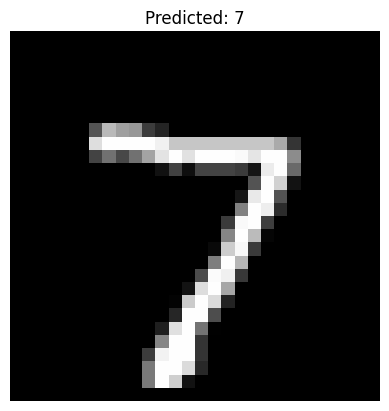

In [10]:
predictions = model.predict(x_test)

# Show one prediction
index = 0
plt.imshow(x_test[index], cmap='gray')
plt.title("Predicted: " + str(np.argmax(predictions[index])))
plt.axis('off')
plt.show()


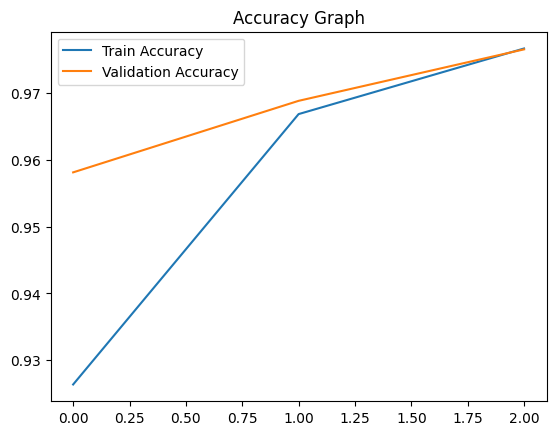

In [11]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()


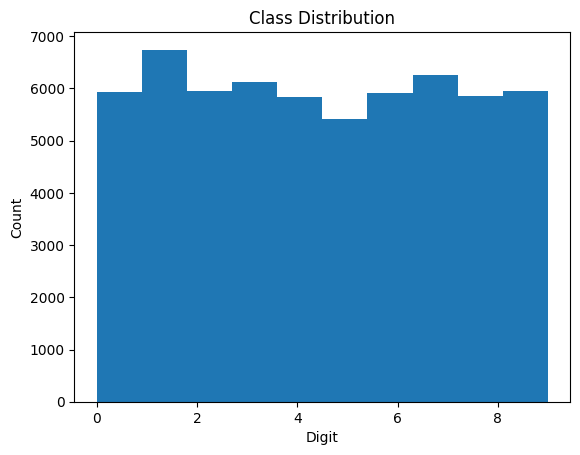

In [12]:
import matplotlib.pyplot as plt

plt.hist(y_train, bins=10)
plt.title("Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()


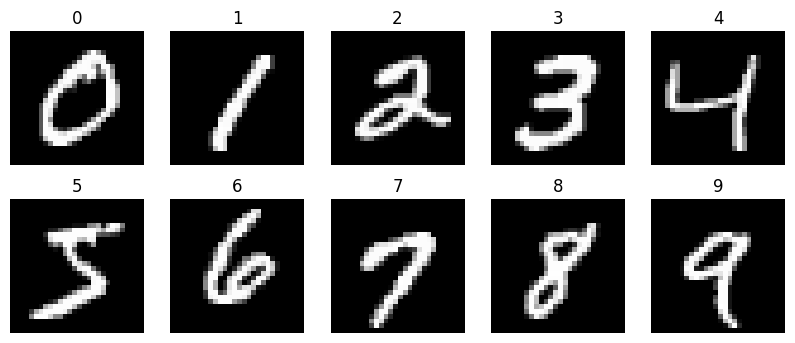

In [13]:
plt.figure(figsize=(10,4))

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    plt.subplot(2,5,digit+1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(str(digit))
    plt.axis('off')

plt.show()


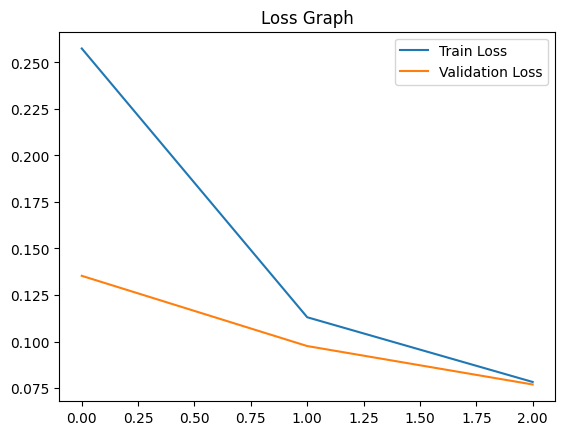

In [14]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


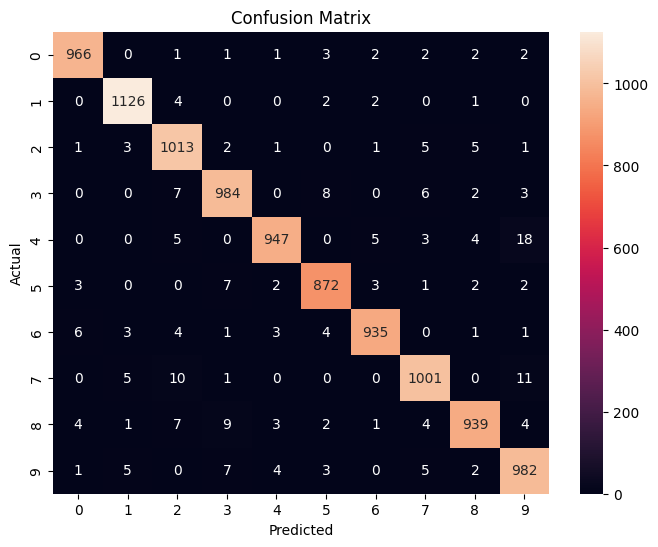

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



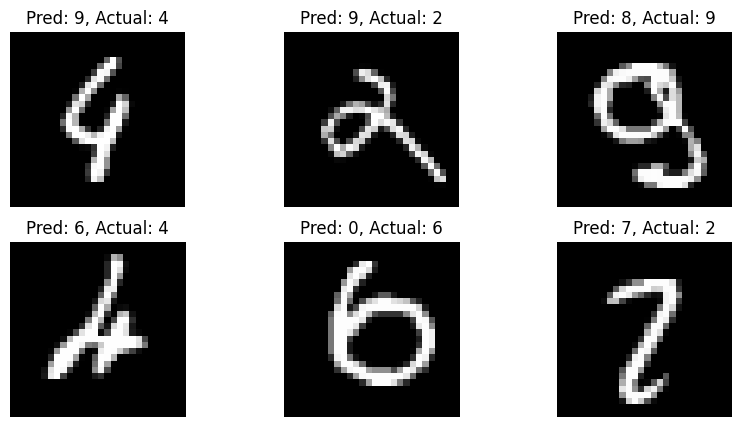

In [16]:
misclassified = np.where(y_pred != y_test)[0]

plt.figure(figsize=(10,5))

for i in range(6):
    idx = misclassified[i]
    plt.subplot(2,3,i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"Pred: {y_pred[idx]}, Actual: {y_test[idx]}")
    plt.axis('off')

plt.show()
